In [1]:
# Inclusão das bibliotecas usadas no trabalho
import numpy as np
import matplotlib.pyplot as plt
import csv

In [2]:

# Função para carregar os dados do CSV
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, 'r') as f:
        leitor = csv.reader(f)
        next(leitor) # Pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1])]) # Idade, salário
            y.append(int(linha[2]))
    return np.array(X), np.array(y)

# Carregando o dataset
X, y = carregar_dados("train_dataset1.csv")
print("Formato dos dados:", X.shape, y.shape)
print("Primeiras amostras:", X[:5], "\nRótulos:", y[:5])

#Lembra que a Árvore de Decisão criava várias linhas perfeitamente horizontais e verticais,
#  dividindo o gráfico em "blocos"?

#O Perceptron faz algo totalmente diferente: ele tenta traçar uma única linha reta diagonal
#  para separar a Classe 0 da Classe 1. Ele é um classificador linear.

Formato dos dados: (140, 2) (140,)
Primeiras amostras: [[ 0.25401832 -0.4023906 ]
 [ 0.18088266  0.5108872 ]
 [ 0.22715201  0.46771486]
 [-0.12283202  0.50263486]
 [ 0.43719255 -0.57959177]] 
Rótulos: [-1  1  1  1 -1]


In [8]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000, weight_init="random"):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.weight_init = weight_init
        self.bias = None
        self.errors_per_epochs = [] # Armazena o erro a cada época

    # Inicializando os pesos de forma customizada
    def _initialize_weights(self, n_features):
        """ Inicializa os pesos de acordo com o método escolhido """
        if self.weight_init == "random":
            self.weights = np.random.rand(n_features)
            self.bias = np.random.rand()
        elif self.weight_init == "zeros":
            self.weights = np.zeros(n_features)
            self.bias = 0
        elif self.weight_init == "normal":
            self.weights = np.random.randn(n_features) * 0.01 # Pequenos valores gaussianos
            self.bias = np.random.randn() * 0.01
        else:
            raise ValueError("Opção inválida para inicialização dos pesos")
        
    def fit(self, X, y):
        n_samples, n_feaures = X.shape
        #self.weights = np.zeros(n_features)
        self._initialize_weights(n_feaures) # Inicializa os pesos dinamicamente
        self.bias = 0

        for epoch in range(self.n_epochs):
            errors = 0 # Contador de erro por épocas

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = np.sign(linear_output)

                # Atualização dos pesos se houver erro
                if y_pred != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1 # Incrementa erro se classificação errada

            # Armazena a taxa de erro (erros / total de amostras)
            self.errors_per_epochs.append(errors / n_samples)

            # Parada antecipada se não houver erros
            if errors == 0:
                break

        # Após o treinamento, calcular e exibir estatísticas
        self._print_training_summary(X, y, epoch + 1)

    # Método para exibir a acurácia e pesos finais
    def _print_training_summary(self, X, y, epochs):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print("\n======== Resumo do treinamento ========")
        print(f"Acurácia no conjunto de treino: {accuracy:.2f}%")
        print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("========================================\n")

    # Retorna a predição com base no treinamento do Perceptron
    def predict(self, X):
        return np.sign(np.dot(X, self.weights) + self.bias)
    
    def predict2(self, X, y, y_true=None):
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        if y_true is not None:
            self.predict_summary(X, y_true, 0, "Teste")
        return y_pred
    
    # Calculando as métricas da predição
    def predict_summary(self, X, y, epochs, phase):
        """ Método para exibir a acurácia, desvio padrão e pesos finais """
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print(f"\n======= Resumdo do {phase} =======")
        print(f"Acurácia no conjunto de {phase.lower()}: {accuracy:.2f}%")
        print(f"Desvio padrão dos pesos: {std_dev:.5f}")
        if epochs > 0:
            print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("====================================\n")

    # Plota o gráfico da evolução dos erros ao longo das épocas de treinamento
    def plot_error(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.errors_per_epochs, marker='o', linestyle='-')
        plt.xlabel("Época")
        plt.ylabel("Taxa de erro")
        plt.title("Evolução do erro ao longo das épocas")
        plt.grid()
        plt.show()

In [5]:
# Gráfico da "fronteira" gerado pelo Perceptron
def plot_decision_boundary(X, y, model, title="Fronteira de Decisão do Perceptron"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar o gráfico
    plt.countourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.show()    

In [6]:
# Função para plotar lado a lado: dataset e fronteira de decisão
def plot_comparison(X, y, model):
    # Criar uma grade para o plano cartesiano
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar os subplots (1 linha, 2 colunas)
    flg, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Subplot 1 - Fronteira de decisão
    axes[0].contourf(xx, yy, Z, alpha=0.3)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[0].set_xlabel("X1")
    axes[0].set_ylabel("X2")
    axes[0].set_title("Fronteira de Decisão do Perceptron")

    # Subplot 2 - Apenas os dados
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[1].set_xlabel("X1")
    axes[1].set_ylabel("X2")
    axes[1].set_title("Distribuição dos Dados do Dataset")

    plt.tight_layout()
    plt.show()


======== Resumo do treinamento ========
Acurácia no conjunto de treino: 94.29%
Número total de épocas: 100
Pesos finais aprendidos: [-0.65595793  0.77138512]
Bias final: 0.30000000000000004



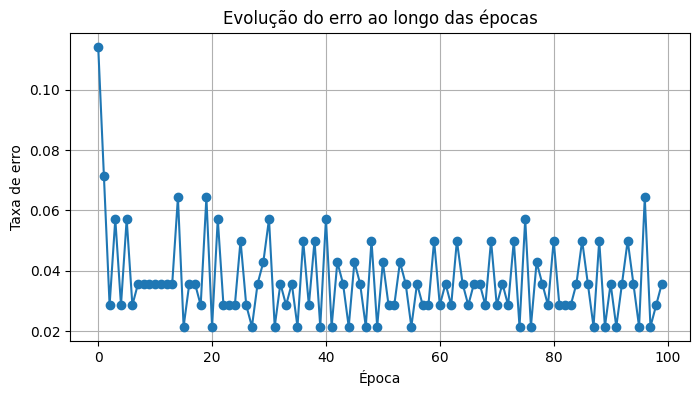

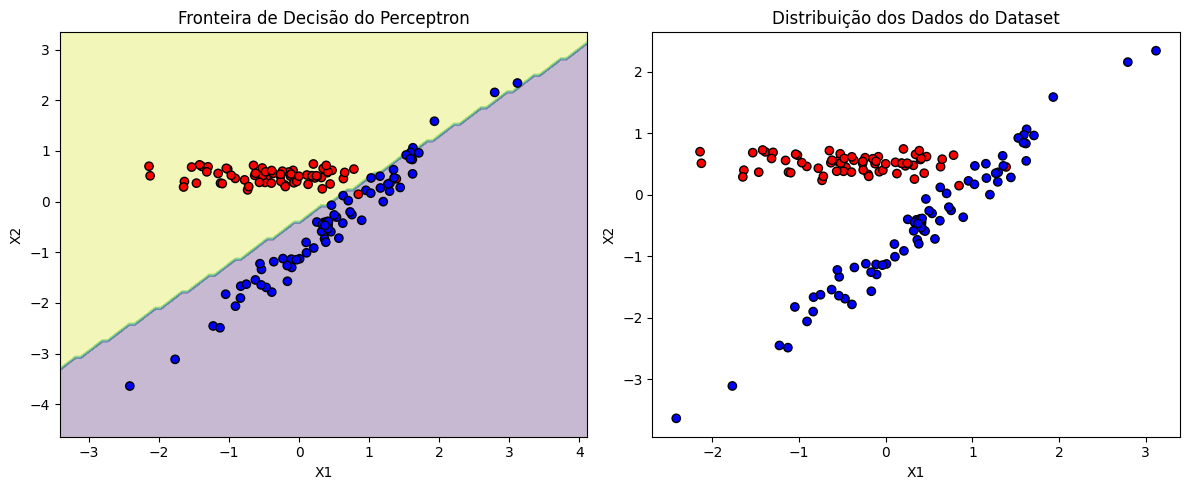

In [9]:
# Dataset 1 - Importando e visualizando o dataset de TREINO
train_dataset1 = np.loadtxt("train_dataset1.csv", delimiter=",", skiprows=1, dtype=float)

# Definição das entradas
X = train_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
y_pred = perceptron.predict2(X, y)

# Plotar a evolução do erro
perceptron.plot_error()

print("")

# Plot dos gráficos lado a lado
plot_comparison(X, y, perceptron)